In [2]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
import warnings
from pathlib import Path
import sys
import os
from datetime import datetime

project_root = Path.cwd().parent.parent
project_root_str = str(project_root)

if project_root_str not in sys.path:
    sys.path.insert(0, project_root_str)

os.chdir(project_root_str)

warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)

In [ ]:
# # ── FeatureEngineer: raw.{nba,wnba}_* → multi-season training frame ───────────
# # Builds player (base/adv/tracking) + team (base/adv + opp matchup) features
# # for each season, then concatenates into one player-game frame.
# from src.pipeline.features.build_features import FeatureEngineer

# PROCESSED_DIR = Path("data/processed")
# PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

# # Toggle: "nba" or "wnba"
# LEAGUE = "wnba"
# SEASON_TYPE = "Regular Season"
# FORCE_REBUILD_FEATURES = True

# SEASONS_BY_LEAGUE = {
#     "nba": ["2021-22", "2022-23", "2023-24", "2024-25", "2025-26"],
#     "wnba": ["2018", "2019", "2020", "2021", "2022", "2023", "2024", "2025", "2026"],
# }
# SEASONS = SEASONS_BY_LEAGUE[LEAGUE]

# season_frames = []
# for season in SEASONS:
#     engineer = FeatureEngineer(
#         season=season,
#         season_type=SEASON_TYPE,
#         league=LEAGUE,
#         processed_data_dir=str(PROCESSED_DIR),
#     )
#     season_path = Path(engineer.training_parquet_path())

#     if season_path.exists() and not FORCE_REBUILD_FEATURES:
#         season_df = pd.read_parquet(season_path)
#         print(f"Loaded {season_path.name}: {season_df.shape[0]:,} rows × {season_df.shape[1]} cols")
#     else:
#         season_df = engineer.run()
#         if season_df is None:
#             raise RuntimeError(f"FeatureEngineer returned no data for {LEAGUE} {season} {SEASON_TYPE}")
#         print(f"Built {season_path.name}: {season_df.shape[0]:,} rows × {season_df.shape[1]} cols")

#     season_frames.append(season_df)

# feats = pd.concat(season_frames, ignore_index=True)
# print(f"\nCombined feats ({LEAGUE}): {feats.shape[0]:,} rows × {feats.shape[1]} cols")
# print(feats["season_year"].value_counts().sort_index())
# feats.head()


Loading raw WNBA data from Supabase (2018 Regular Season)...
  read raw.wnba_player_base — 4,418 rows
  read raw.wnba_player_adv — 4,418 rows
  read raw.wnba_team_base — 440 rows
  read raw.wnba_team_adv — 440 rows
  read raw.wnba_start_positions — 401 rows
  Loaded 440 team base records
  Loaded 440 team adv records
  Loaded 4,418 player base records
  Loaded 4,418 player adv records
  Loaded 401 tracking records

Creating player base features...
  base: 17 stats × (3 ewm + season_avg + lag1) on 4,418 rows

Creating player adv features...
  adv: 14 stats × (3 ewm + season_avg + lag1) on 4,418 rows

Creating player tracking features...
  merged date/season from player_base → 401 rows
  starting flag: 170 / 401 starter rows
  track: 13 stats × (3 ewm + season_avg + lag1) on 401 rows

Creating team features...
  Team base features created.

Creating matchup team base features...
  Attached 33 opp EWM cols → 440 team-game rows

Creating team adv features...
  Team adv features created.

C

,game_id,player_id,team_id,player_name,game_date,season_year,matchup,minutes,pts_per_min,fga_per_min,fg3a_per_min,fta_per_min,oreb_per_min,dreb_per_min,reb_per_min,ast_per_min,tov_per_min,stl_per_min,blk_per_min,blka_per_min,games_played,base_min_ewm_hl5,base_min_ewm_hl10,base_min_ewm_hl20,base_min_lag1,base_min_season_avg,base_fg_pct_ewm_hl5,base_fg_pct_ewm_hl10,base_fg_pct_ewm_hl20,base_fg_pct_lag1,base_fg_pct_season_avg,base_fg3_pct_ewm_hl5,base_fg3_pct_ewm_hl10,base_fg3_pct_ewm_hl20,base_fg3_pct_lag1,base_fg3_pct_season_avg,base_ft_pct_ewm_hl5,base_ft_pct_ewm_hl10,base_ft_pct_ewm_hl20,base_ft_pct_lag1,base_ft_pct_season_avg,base_plus_minus_ewm_hl5,base_plus_minus_ewm_hl10,base_plus_minus_ewm_hl20,base_plus_minus_lag1,base_plus_minus_season_avg,base_pts_per_min_ewm_hl5,base_pts_per_min_ewm_hl10,base_pts_per_min_ewm_hl20,base_pts_per_min_lag1,base_pts_per_min_season_avg,base_fga_per_min_ewm_hl5,base_fga_per_min_ewm_hl10,base_fga_per_min_ewm_hl20,base_fga_per_min_lag1,base_fga_per_min_season_avg,base_fg3a_per_min_ewm_hl5,base_fg3a_per_min_ewm_hl10,base_fg3a_per_min_ewm_hl20,base_fg3a_per_min_lag1,base_fg3a_per_min_season_avg,base_fta_per_min_ewm_hl5,base_fta_per_min_ewm_hl10,base_fta_per_min_ewm_hl20,base_fta_per_min_lag1,base_fta_per_min_season_avg,base_oreb_per_min_ewm_hl5,base_oreb_per_min_ewm_hl10,base_oreb_per_min_ewm_hl20,base_oreb_per_min_lag1,base_oreb_per_min_season_avg,base_dreb_per_min_ewm_hl5,base_dreb_per_min_ewm_hl10,base_dreb_per_min_ewm_hl20,base_dreb_per_min_lag1,base_dreb_per_min_season_avg,base_reb_per_min_ewm_hl5,base_reb_per_min_ewm_hl10,base_reb_per_min_ewm_hl20,base_reb_per_min_lag1,base_reb_per_min_season_avg,base_ast_per_min_ewm_hl5,base_ast_per_min_ewm_hl10,base_ast_per_min_ewm_hl20,base_ast_per_min_lag1,base_ast_per_min_season_avg,base_tov_per_min_ewm_hl5,base_tov_per_min_ewm_hl10,base_tov_per_min_ewm_hl20,base_tov_per_min_lag1,base_tov_per_min_season_avg,base_stl_per_min_ewm_hl5,base_stl_per_min_ewm_hl10,base_stl_per_min_ewm_hl20,base_stl_per_min_lag1,base_stl_per_min_season_avg,base_blk_per_min_ewm_hl5,base_blk_per_min_ewm_hl10,base_blk_per_min_ewm_hl20,base_blk_per_min_lag1,base_blk_per_min_season_avg,base_blka_per_min_ewm_hl5,base_blka_per_min_ewm_hl10,base_blka_per_min_ewm_hl20,base_blka_per_min_lag1,base_blka_per_min_season_avg,adv_off_rating_ewm_hl5,adv_off_rating_ewm_hl10,adv_off_rating_ewm_hl20,adv_off_rating_lag1,adv_off_rating_season_avg,adv_def_rating_ewm_hl5,adv_def_rating_ewm_hl10,adv_def_rating_ewm_hl20,adv_def_rating_lag1,adv_def_rating_season_avg,adv_net_rating_ewm_hl5,adv_net_rating_ewm_hl10,adv_net_rating_ewm_hl20,adv_net_rating_lag1,adv_net_rating_season_avg,adv_ast_pct_ewm_hl5,adv_ast_pct_ewm_hl10,adv_ast_pct_ewm_hl20,adv_ast_pct_lag1,adv_ast_pct_season_avg,adv_ast_ratio_ewm_hl5,adv_ast_ratio_ewm_hl10,adv_ast_ratio_ewm_hl20,adv_ast_ratio_lag1,adv_ast_ratio_season_avg,adv_oreb_pct_ewm_hl5,adv_oreb_pct_ewm_hl10,adv_oreb_pct_ewm_hl20,adv_oreb_pct_lag1,adv_oreb_pct_season_avg,adv_dreb_pct_ewm_hl5,adv_dreb_pct_ewm_hl10,adv_dreb_pct_ewm_hl20,adv_dreb_pct_lag1,adv_dreb_pct_season_avg,adv_reb_pct_ewm_hl5,adv_reb_pct_ewm_hl10,adv_reb_pct_ewm_hl20,adv_reb_pct_lag1,adv_reb_pct_season_avg,adv_efg_pct_ewm_hl5,adv_efg_pct_ewm_hl10,adv_efg_pct_ewm_hl20,adv_efg_pct_lag1,adv_efg_pct_season_avg,adv_ts_pct_ewm_hl5,adv_ts_pct_ewm_hl10,adv_ts_pct_ewm_hl20,adv_ts_pct_lag1,adv_ts_pct_season_avg,adv_usg_pct_ewm_hl5,adv_usg_pct_ewm_hl10,adv_usg_pct_ewm_hl20,adv_usg_pct_lag1,adv_usg_pct_season_avg,adv_pace_ewm_hl5,adv_pace_ewm_hl10,adv_pace_ewm_hl20,adv_pace_lag1,adv_pace_season_avg,adv_poss_ewm_hl5,adv_poss_ewm_hl10,adv_poss_ewm_hl20,adv_poss_lag1,adv_poss_season_avg,adv_pie_ewm_hl5,adv_pie_ewm_hl10,adv_pie_ewm_hl20,adv_pie_lag1,adv_pie_season_avg,starting,orbc_per_min,drbc_per_min,rbc_per_min,tchs_per_min,sast_per_min,ftast_per_min,pass_per_min,cfga_per_min,ufga_per_min,dfga_per_min,track_minutes_ewm_hl5,track_minutes_ewm_hl10,track_minutes_ewm_hl20,track_minutes_lag1,track_minutes_season_avg,track_spd

## Load Data
**Use Cell above only if you need to repull data from database**

In [8]:
from src.pipeline.features.context_features import ContextFeatureEngineer

s22 = pd.read_parquet('data/processed/2021-22_Regular_Season_training_data.parquet')
s22 = ContextFeatureEngineer().enrich(s22)
s22['position_encoded'] = s22['pos'].map({'PG': 1, 'SG': 2, 'SF': 3, 'PF': 4, 'C': 5})

s23 = pd.read_parquet('data/processed/2022-23_Regular_Season_training_data.parquet')
s23 = ContextFeatureEngineer().enrich(s23)
s23['position_encoded'] = s23['pos'].map({'PG': 1, 'SG': 2, 'SF': 3, 'PF': 4, 'C': 5})

s24 = pd.read_parquet('data/processed/2023-24_Regular_Season_training_data.parquet')
s24 = ContextFeatureEngineer().enrich(s24)
s24['position_encoded'] = s24['pos'].map({'PG': 1, 'SG': 2, 'SF': 3, 'PF': 4, 'C': 5})

s25 = pd.read_parquet('data/processed/2024-25_Regular_Season_training_data.parquet')
s25 = ContextFeatureEngineer().enrich(s25)
s25['position_encoded'] = s25['pos'].map({'PG': 1, 'SG': 2, 'SF': 3, 'PF': 4, 'C': 5})

s26 = pd.read_parquet('data/processed/2025-26_Regular_Season_training_data.parquet')
s26 = ContextFeatureEngineer().enrich(s26)
s26['position_encoded'] = s26['pos'].map({'PG': 1, 'SG': 2, 'SF': 3, 'PF': 4, 'C': 5})

df = pd.concat([s22, s23, s24, s25, s26], ignore_index=True)
df.sample(10)


Context features (pos, rest, trends, ranks, std/var, games played)

Merging player positions...
  loaded 624 positions from nba_2022_players.csv (season=2021-22)
  pos filled on 25,921 / 26,039 rows (1 season file(s))

Adding games_played to date...
  games_played + season_games_played

Adding rest / back-to-back...
  days_rest + is_back_to_back (3,830 B2B rows)

Adding fatigue window features...
  games_played_last_7/14_days + min_sum_last_7_days (from minutes)

Adding 5v20 trends...
  added 7 trend cols: ['base_min_trend_5v20', 'base_pts_per_min_trend_5v20', 'adv_ts_pct_trend_5v20', 'adv_usg_pct_trend_5v20', 'base_ast_per_min_trend_5v20', 'base_oreb_per_min_trend_5v20', 'base_dreb_per_min_trend_5v20']

Adding within-team ranks...
  added 7 rank cols: ['team_pts_per_min_rank_l10', 'team_ast_per_min_rank_l10', 'team_oreb_per_min_rank_l10', 'team_dreb_per_min_rank_l10', 'team_ts_pct_rank_l10', 'team_usg_pct_rank_l10', 'team_min_rank_l10']

Adding rolling team rank for pts_per_min (L10)

,game_id,player_id,team_id,player_name,game_date,season_year,matchup,minutes,pts_per_min,fga_per_min,fg3a_per_min,fta_per_min,oreb_per_min,dreb_per_min,reb_per_min,ast_per_min,tov_per_min,stl_per_min,blk_per_min,blka_per_min,games_played,base_min_ewm_hl5,base_min_ewm_hl10,base_min_ewm_hl20,base_min_lag1,base_min_season_avg,base_fg_pct_ewm_hl5,base_fg_pct_ewm_hl10,base_fg_pct_ewm_hl20,base_fg_pct_lag1,base_fg_pct_season_avg,base_fg3_pct_ewm_hl5,base_fg3_pct_ewm_hl10,base_fg3_pct_ewm_hl20,base_fg3_pct_lag1,base_fg3_pct_season_avg,base_ft_pct_ewm_hl5,base_ft_pct_ewm_hl10,base_ft_pct_ewm_hl20,base_ft_pct_lag1,base_ft_pct_season_avg,base_plus_minus_ewm_hl5,base_plus_minus_ewm_hl10,base_plus_minus_ewm_hl20,base_plus_minus_lag1,base_plus_minus_season_avg,base_pts_per_min_ewm_hl5,base_pts_per_min_ewm_hl10,base_pts_per_min_ewm_hl20,base_pts_per_min_lag1,base_pts_per_min_season_avg,base_fga_per_min_ewm_hl5,base_fga_per_min_ewm_hl10,base_fga_per_min_ewm_hl20,base_fga_per_min_lag1,base_fga_per_min_season_avg,base_fg3a_per_min_ewm_hl5,base_fg3a_per_min_ewm_hl10,base_fg3a_per_min_ewm_hl20,base_fg3a_per_min_lag1,base_fg3a_per_min_season_avg,base_fta_per_min_ewm_hl5,base_fta_per_min_ewm_hl10,base_fta_per_min_ewm_hl20,base_fta_per_min_lag1,base_fta_per_min_season_avg,base_oreb_per_min_ewm_hl5,base_oreb_per_min_ewm_hl10,base_oreb_per_min_ewm_hl20,base_oreb_per_min_lag1,base_oreb_per_min_season_avg,base_dreb_per_min_ewm_hl5,base_dreb_per_min_ewm_hl10,base_dreb_per_min_ewm_hl20,base_dreb_per_min_lag1,base_dreb_per_min_season_avg,base_reb_per_min_ewm_hl5,base_reb_per_min_ewm_hl10,base_reb_per_min_ewm_hl20,base_reb_per_min_lag1,base_reb_per_min_season_avg,base_ast_per_min_ewm_hl5,base_ast_per_min_ewm_hl10,base_ast_per_min_ewm_hl20,base_ast_per_min_lag1,base_ast_per_min_season_avg,base_tov_per_min_ewm_hl5,base_tov_per_min_ewm_hl10,base_tov_per_min_ewm_hl20,base_tov_per_min_lag1,base_tov_per_min_season_avg,base_stl_per_min_ewm_hl5,base_stl_per_min_ewm_hl10,base_stl_per_min_ewm_hl20,base_stl_per_min_lag1,base_stl_per_min_season_avg,base_blk_per_min_ewm_hl5,base_blk_per_min_ewm_hl10,base_blk_per_min_ewm_hl20,base_blk_per_min_lag1,base_blk_per_min_season_avg,base_blka_per_min_ewm_hl5,base_blka_per_min_ewm_hl10,base_blka_per_min_ewm_hl20,base_blka_per_min_lag1,base_blka_per_min_season_avg,adv_off_rating_ewm_hl5,adv_off_rating_ewm_hl10,adv_off_rating_ewm_hl20,adv_off_rating_lag1,adv_off_rating_season_avg,adv_def_rating_ewm_hl5,adv_def_rating_ewm_hl10,adv_def_rating_ewm_hl20,adv_def_rating_lag1,adv_def_rating_season_avg,adv_net_rating_ewm_hl5,adv_net_rating_ewm_hl10,adv_net_rating_ewm_hl20,adv_net_rating_lag1,adv_net_rating_season_avg,adv_ast_pct_ewm_hl5,adv_ast_pct_ewm_hl10,adv_ast_pct_ewm_hl20,adv_ast_pct_lag1,adv_ast_pct_season_avg,adv_ast_ratio_ewm_hl5,adv_ast_ratio_ewm_hl10,adv_ast_ratio_ewm_hl20,adv_ast_ratio_lag1,adv_ast_ratio_season_avg,adv_oreb_pct_ewm_hl5,adv_oreb_pct_ewm_hl10,adv_oreb_pct_ewm_hl20,adv_oreb_pct_lag1,adv_oreb_pct_season_avg,adv_dreb_pct_ewm_hl5,adv_dreb_pct_ewm_hl10,adv_dreb_pct_ewm_hl20,adv_dreb_pct_lag1,adv_dreb_pct_season_avg,adv_reb_pct_ewm_hl5,adv_reb_pct_ewm_hl10,adv_reb_pct_ewm_hl20,adv_reb_pct_lag1,adv_reb_pct_season_avg,adv_efg_pct_ewm_hl5,adv_efg_pct_ewm_hl10,adv_efg_pct_ewm_hl20,adv_efg_pct_lag1,adv_efg_pct_season_avg,adv_ts_pct_ewm_hl5,adv_ts_pct_ewm_hl10,adv_ts_pct_ewm_hl20,adv_ts_pct_lag1,adv_ts_pct_season_avg,adv_usg_pct_ewm_hl5,adv_usg_pct_ewm_hl10,adv_usg_pct_ewm_hl20,adv_usg_pct_lag1,adv_usg_pct_season_avg,adv_pace_ewm_hl5,adv_pace_ewm_hl10,adv_pace_ewm_hl20,adv_pace_lag1,adv_pace_season_avg,adv_poss_ewm_hl5,adv_poss_ewm_hl10,adv_poss_ewm_hl20,adv_poss_lag1,adv_poss_season_avg,adv_pie_ewm_hl5,adv_pie_ewm_hl10,adv_pie_ewm_hl20,adv_pie_lag1,adv_pie_season_avg,starting,orbc_per_min,drbc_per_min,rbc_per_min,tchs_per_min,sast_per_min,ftast_per_min,pass_per_min,cfga_per_min,ufga_per_min,dfga_per_min,track_minutes_ewm_hl5,track_minutes_ewm_hl10,track_minutes_ewm_hl20,track_minutes_lag1,track_minutes_season_avg,track_spd

In [9]:
print(f"Total number of duplicates: {df.duplicated(subset=['game_id', 'player_id']).sum()}")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
df[['minutes','pts_per_min', 'ast_per_min', 'reb_per_min']].describe()


Total number of duplicates: 0
Rows: 131291
Columns: 453


,minutes,pts_per_min,ast_per_min,reb_per_min
count,131291.000000,131279.000000,131279.000000,131279.000000
mean,22.617312,0.429593,0.099152,0.185916
std,10.761219,0.317961,0.117714,0.906028
min,0.000000,0.000000,0.000000,0.000000
25%,14.876667,0.229885,0.000000,0.083548
50%,23.633333,0.410526,0.078632,0.156556
75%,31.333333,0.599144,0.147420,0.251046
max,56.516667,30.000000,22.222222,300.000000


### Trail Features

In [115]:
df['ts_pct_x_usg_pct'] = df['adv_ts_pct_season_avg'] * df['adv_usg_pct_season_avg']

In [ ]:
PPM_FEATURES = [
    # Recent scoring performance (core signal)
    'base_pts_per_min_ewm_hl5',
    'base_pts_per_min_season_avg',

    # Shot volume / usage (scoring opportunity)
    'base_fga_per_min_ewm_hl10',
    'base_fg3a_per_min_ewm_hl10',
    'base_fta_per_min_ewm_hl10',
    'ts_pct_x_usg_pct',
    'adv_poss_ewm_hl5',

    # Shot creation / touches (tracking)
    'track_tchs_per_min_ewm_hl10',
    'track_cfga_per_min_ewm_hl10',
    'track_ufga_per_min_ewm_hl10',

    # Matchup/context (defense faced, pace)
    'opp_def_rating_ewm_hl10',
    'opp_pace_ewm_hl10',
    'team_pace_ewm_hl10'
]
PPM_FEATURES = list(set(PPM_FEATURES))

In [147]:
print(f"Number of features: {df[PPM_FEATURES].shape[1]}")
print(f"Number of rows: {df[PPM_FEATURES].shape[0]}")

Number of features: 13
Number of rows: 111462


In [132]:
df = df[(df['minutes'] >= 5) | (df['starting'] == 1)]
print(f"After filtering games under 10 minutes: {df[PPM_FEATURES].shape[0]} rows")

After filtering games under 10 minutes: 111462 rows


In [133]:
# ── Train/holdout split ───────────────────────────────────────────────────────
# 2025-26 is held out entirely. The model never sees it during training
# or hyperparameter evaluation. Evaluate on it ONCE at the very end.

HOLDOUT_SEASON = "2025-26"
ID_COLS = ["game_id", "player_id", "season_year", "player_name", "game_date"]
TARGET_COL = "pts_per_min"
ROLE_COL = "starting"

df_model = df[df["season_year"] != HOLDOUT_SEASON].copy()   # 2021-22 → 2024-25
df_holdout = df[df["season_year"] == HOLDOUT_SEASON].copy()  # 2025-26 blind test

KEEP_COLS = list(dict.fromkeys(
    PPM_FEATURES + ID_COLS + [TARGET_COL, ROLE_COL, "minutes"]
))

ppm_df = (
    df_model[KEEP_COLS]
    .sort_values("game_date")
    .reset_index(drop=True)
)

ppm_holdout = (
    df_holdout[KEEP_COLS]
    .sort_values("game_date")
    .reset_index(drop=True)
)

X = ppm_df[PPM_FEATURES].copy()
y = ppm_df[TARGET_COL]

print(f"Train pool (2021-22 → 2024-25) : {len(ppm_df):,} rows")
print(f"Holdout   (2025-26)            : {len(ppm_holdout):,} rows")
print(f"Date range (train)   : {ppm_df['game_date'].min().date()} → {ppm_df['game_date'].max().date()}")
print(f"Date range (holdout) : {ppm_holdout['game_date'].min().date()} → {ppm_holdout['game_date'].max().date()}")


Train pool (2021-22 → 2024-25) : 88,737 rows
Holdout   (2025-26)            : 22,725 rows
Date range (train)   : 2021-10-19 → 2025-04-13
Date range (holdout) : 2025-10-21 → 2026-04-12


In [134]:
from sklearn.model_selection import TimeSeriesSplit

quantiles = [0.10, 0.50, 0.90]
# Best params: {'n_estimators': 1300, 'max_depth': 4, 'learning_rate': 0.014326702971361573, 'subsample': 0.6865962871949852, 'colsample_bytree': 0.5990331287465477, 
# 'reg_alpha': 0.11598736995372527, 'reg_lambda': 0.48362325914167376, 'min_child_weight': 6}

XGB_PARAMS = dict(
    objective             = "reg:quantileerror",
    n_estimators          = 1300,
    max_depth             = 4,
    learning_rate         = 0.014326702971361573,
    subsample             = 0.6865962871949852,
    colsample_bytree      = 0.5990331287465477,
    reg_alpha             = 0.11598736995372527,
    reg_lambda            = 0.48362325914167376,
    min_child_weight      = 6,
    n_jobs                = -1,
    random_state          = 42,
    early_stopping_rounds = 50,
)


def fit_quantile_models(X_train, y_train, X_val, y_val):
    """Train one XGB quantile model per quantile, return preds dict."""
    models = {}
    preds  = {}
    for q in quantiles:
        m = XGBRegressor(**XGB_PARAMS, quantile_alpha=q)
        m.fit(X_train, y_train,
              eval_set=[(X_val, y_val)],
              verbose=False)
        key         = f"q_{q:.2f}"
        models[key] = m
        preds[key]  = m.predict(X_val)
    return models, preds

In [135]:
# ── Helpers ───────────────────────────────────────────────────────────────────

PPM_TIERS = {
    "<0.3 pts/min":    lambda a: a < 0.3,
    "0.3-0.5 pts/min": lambda a: (a >= 0.3) & (a < 0.5),
    "0.5-0.7 pts/min": lambda a: (a >= 0.5) & (a < 0.7),
    "0.7+ pts/min":    lambda a: a >= 0.7,
}

FEATURE_COLS = list(PPM_FEATURES)


def score_fold(actual, preds, models, fold_label, starting=None):
    """
    Score a single fold.
    Accepts `starting` (bool/int array) and reports stratified MAE + coverage
    across roles and PPM tiers.
    """
    lower  = preds["q_0.10"]
    median = preds["q_0.50"]
    upper  = preds["q_0.90"]

    mae      = mean_absolute_error(actual, median)
    r2       = r2_score(actual, median)
    coverage = np.mean((actual >= lower) & (actual <= upper))

    metrics = {
        "fold":           fold_label,
        "n":              len(actual),
        "mae":            mae,
        "r2":             r2,
        "coverage_80pct": coverage,
        "best_iters":     {k: models[k].best_iteration for k in models},
    }

    print(f"\n{fold_label}")
    print(f"  Overall  | n={len(actual):5d} | MAE: {mae:.4f} | R²: {r2:.3f} | 80% Coverage: {coverage:.1%}")

    # ── Role stratification (starter vs bench) ────────────────────────────────
    if starting is not None:
        for role, mask in [("Starters", starting == 1), ("Bench", starting == 0)]:
            if mask.sum() == 0:
                continue
            r_mae = mean_absolute_error(actual[mask], median[mask])
            r_cov = np.mean((actual[mask] >= lower[mask]) & (actual[mask] <= upper[mask]))
            metrics[f"mae_{role}"]      = r_mae
            metrics[f"coverage_{role}"] = r_cov
            print(f"  {role:10s} | n={mask.sum():5d} | MAE: {r_mae:.4f} | Coverage: {r_cov:.1%}")

    # ── PPM-tier stratification ────────────────────────────────────────────────
    for tier, fn in PPM_TIERS.items():
        mask = fn(actual)
        if mask.sum() == 0:
            continue
        t_mae = mean_absolute_error(actual[mask], median[mask])
        t_cov = np.mean((actual[mask] >= lower[mask]) & (actual[mask] <= upper[mask]))
        metrics[f"mae_{tier}"]      = t_mae
        metrics[f"coverage_{tier}"] = t_cov
        print(f"  {tier:18s} | n={mask.sum():5d} | MAE: {t_mae:.4f} | Coverage: {t_cov:.1%}")

    return metrics


# ════════════════════════════════════════════════════════════════════════════
# PHASE 1 — TimeSeriesSplit (feature selection / hyperparam comparison only)
# ════════════════════════════════════════════════════════════════════════════

print("── Phase 1: TimeSeriesSplit ─────────────────────────────────────────")
tscv         = TimeSeriesSplit(n_splits=5)
tscv_results = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X)):
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
    starting_val = ppm_df["starting"].iloc[val_idx].values

    models, preds = fit_quantile_models(X_tr, y_tr, X_val, y_val)
    metrics = score_fold(y_val.values, preds, models,
                         f"TSCV fold {fold+1}", starting=starting_val)
    tscv_results.append(metrics)

maes = [r["mae"]            for r in tscv_results]
r2s  = [r["r2"]             for r in tscv_results]
covs = [r["coverage_80pct"] for r in tscv_results]
print(f"\nTimeSeriesSplit Summary")
print(f"  MAE      : {np.mean(maes):.4f} ± {np.std(maes):.4f}")
print(f"  R²       : {np.mean(r2s):.3f}  ± {np.std(r2s):.3f}")
print(f"  Coverage : {np.mean(covs):.1%} ± {np.std(covs):.1%}  (target ~80%)")


# ════════════════════════════════════════════════════════════════════════════
# PHASE 2 — Walk-Forward (date-based, production simulation)
#
# Splits are on unique game_date values, not row indices.
# This ensures no single game date is split across train/val
# (avoids intra-game leakage).
# ════════════════════════════════════════════════════════════════════════════

print("\n── Phase 2: Walk-Forward Validation (date-based) ───────────────────")

ppm_df["game_date"] = pd.to_datetime(ppm_df["game_date"])
assert ppm_df["game_date"].is_monotonic_increasing, "ppm_df must be sorted by game_date"

unique_dates = ppm_df["game_date"].unique()          # sorted unique game dates
n_dates      = len(unique_dates)

TRAIN_WINDOW = round(n_dates * 0.50)                 # dates in each training window
STEP_SIZE    = round(n_dates * 0.10)                 # dates to advance each fold
N_FOLDS      = 4

print(f"Unique game dates in pool : {n_dates}")
print(f"Training window           : {TRAIN_WINDOW} dates (~{TRAIN_WINDOW/n_dates:.0%})")
print(f"Step size                 : {STEP_SIZE} dates (~{STEP_SIZE/n_dates:.0%})")

wf_results  = []
models_last = None   # will hold the final fold's models for downstream cells

for fold in range(N_FOLDS):
    d_train_start = fold * STEP_SIZE
    d_train_end   = d_train_start + TRAIN_WINDOW
    d_val_end     = d_train_end   + STEP_SIZE

    if d_val_end > n_dates:
        print(f"\nFold {fold+1}: not enough dates remaining — stopping at {fold} folds.")
        break

    train_dates = unique_dates[d_train_start:d_train_end]
    val_dates   = unique_dates[d_train_end:d_val_end]

    # Mask on dates so every player in a given game date
    # lands on the same side of the split — no intra-game leakage.
    train_mask = ppm_df["game_date"].isin(train_dates)
    val_mask   = ppm_df["game_date"].isin(val_dates)

    X_tr,  X_val  = X.loc[train_mask],             X.loc[val_mask]
    y_tr,  y_val  = y.loc[train_mask],             y.loc[val_mask]
    starting_val  = ppm_df.loc[val_mask, "starting"].values

    label = (
        f"WF fold {fold+1}  "
        f"({pd.Timestamp(train_dates[-1]).date()} → {pd.Timestamp(val_dates[-1]).date()})"
    )

    models, preds = fit_quantile_models(X_tr, y_tr, X_val, y_val)
    metrics = score_fold(y_val.values, preds, models, label, starting=starting_val)
    metrics.update({
        "train_start": train_dates[0],
        "train_end":   train_dates[-1],
        "val_end":     val_dates[-1],
        # stash masks so downstream cells can reconstruct without retraining
        "train_mask":  train_mask,
        "val_mask":    val_mask,
    })
    wf_results.append(metrics)

    # keep last fold for residual plots + SHAP
    models_last   = models
    preds_last    = preds
    X_val_last    = X_val
    y_val_last    = y_val
    starting_last = starting_val

# ── Walk-forward summary ──────────────────────────────────────────────────────
maes = [r["mae"]            for r in wf_results]
r2s  = [r["r2"]             for r in wf_results]
covs = [r["coverage_80pct"] for r in wf_results]

print(f"\n{'─'*60}")
print(f"Walk-Forward Summary ({len(wf_results)}/{N_FOLDS} folds)")
print(f"  MAE      : {np.mean(maes):.4f} ± {np.std(maes):.4f}")
print(f"  R²       : {np.mean(r2s):.3f}  ± {np.std(r2s):.3f}")
print(f"  Coverage : {np.mean(covs):.1%} ± {np.std(covs):.1%}  (target ~80%)")

# Per-fold coverage table — catches folds where interval collapses
# or over-covers without hiding it in the mean.
print(f"\n{'─'*60}")
print("Per-fold coverage breakdown (target 80%):")
print(f"  {'Fold':<45} {'Coverage':>10}  {'Starters':>10}  {'Bench':>10}")
for r in wf_results:
    s_cov = r.get("coverage_Starters", float('nan'))
    b_cov = r.get("coverage_Bench",    float('nan'))
    print(f"  {r['fold']:<45} {r['coverage_80pct']:>9.1%}  {s_cov:>9.1%}  {b_cov:>9.1%}")

# Stratified MAE summary across all folds
print(f"\nPer-fold MAE by PPM tier:")
tier_keys = list(PPM_TIERS.keys())
header = f"  {'Fold':<45} " + "  ".join(f"{t:>18}" for t in tier_keys)
print(header)
for r in wf_results:
    row = f"  {r['fold']:<45} "
    row += "  ".join(f"{r.get(f'mae_{t}', float('nan')):>18.4f}" for t in tier_keys)
    print(row)

# Drift check
max_mae = max(maes)
print(f"\nMAE over folds (stable = good, rising = model aging):")
for r in wf_results:
    bar = "█" * int((r["mae"] / max_mae) * 20)
    print(f"  {r['fold']:<45} {r['mae']:.4f}  {bar}")

last_fold = wf_results[-1]


── Phase 1: TimeSeriesSplit ─────────────────────────────────────────

TSCV fold 1
  Overall  | n=14789 | MAE: 0.1655 | R²: 0.271 | 80% Coverage: 78.7%
  Starters   | n= 8138 | MAE: 0.1575 | Coverage: 80.0%
  Bench      | n= 6651 | MAE: 0.1752 | Coverage: 77.1%
  <0.3 pts/min       | n= 4393 | MAE: 0.1902 | Coverage: 68.1%
  0.3-0.5 pts/min    | n= 4676 | MAE: 0.0828 | Coverage: 97.8%
  0.5-0.7 pts/min    | n= 3465 | MAE: 0.1511 | Coverage: 89.0%
  0.7+ pts/min       | n= 2255 | MAE: 0.3108 | Coverage: 44.0%

TSCV fold 2
  Overall  | n=14789 | MAE: 0.1620 | R²: 0.309 | 80% Coverage: 80.3%
  Starters   | n= 8255 | MAE: 0.1537 | Coverage: 81.4%
  Bench      | n= 6534 | MAE: 0.1724 | Coverage: 78.9%
  <0.3 pts/min       | n= 4142 | MAE: 0.1905 | Coverage: 67.8%
  0.3-0.5 pts/min    | n= 4738 | MAE: 0.0902 | Coverage: 96.6%
  0.5-0.7 pts/min    | n= 3542 | MAE: 0.1416 | Coverage: 92.1%
  0.7+ pts/min       | n= 2367 | MAE: 0.2863 | Coverage: 51.8%

TSCV fold 3
  Overall  | n=14789 | MAE: 0

In [136]:
# import optuna
# from sklearn.model_selection import TimeSeriesSplit
# from sklearn.metrics import mean_absolute_error
# from xgboost import XGBRegressor

# tscv = TimeSeriesSplit(n_splits=3)  # fewer splits = faster tuning

# def objective(trial):
#     params = {
#         "objective": "reg:quantileerror",
#         "n_estimators": trial.suggest_int("n_estimators", 500, 2000),
#         "max_depth": trial.suggest_int("max_depth", 3, 12),
#         "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
#         "subsample": trial.suggest_float("subsample", 0.5, 1.0),
#         "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
#         "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 5.0, log=True),
#         "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 5.0, log=True),
#         "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
#         "n_jobs": -1,
#         "random_state": 42,
#         "early_stopping_rounds": 50,
#     }
#     maes = []
#     for train_idx, val_idx in tscv.split(X):
#         X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
#         y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
#         m = XGBRegressor(**params, quantile_alpha=0.5)
#         m.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
#         pred = m.predict(X_val)
#         maes.append(mean_absolute_error(y_val, pred))
#     return float(np.mean(maes))

# study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=42))
# study.optimize(objective, n_trials=50, show_progress_bar=True)

# print("Best MAE (mean over TSCV, median model):", study.best_value)
# print("Best params:", study.best_params)

### Residual Visuals

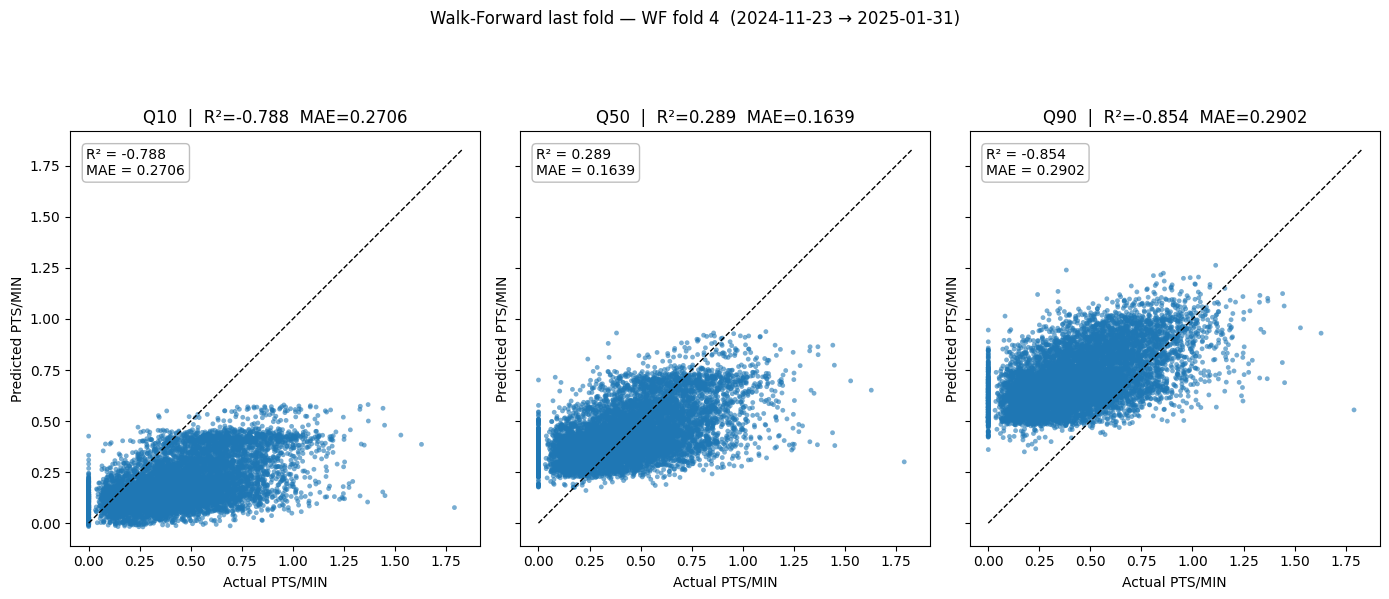

Per-quantile fit on last validation fold:
  Q10: R²=-0.788  MAE=0.2706
  Q50: R²=+0.289  MAE=0.1639
  Q90: R²=-0.854  MAE=0.2902

Coverage per quantile (should match quantile value):
  Q10: 10.1%  (target 10%, delta +0.1%)  ✓
  Q50: 50.5%  (target 50%, delta +0.5%)  ✓
  Q90: 89.7%  (target 90%, delta -0.3%)  ✓

80% interval width (Q10→Q90):
  mean   : 0.5191 pts/min
  median : 0.5172 pts/min
  std    : 0.0546 pts/min


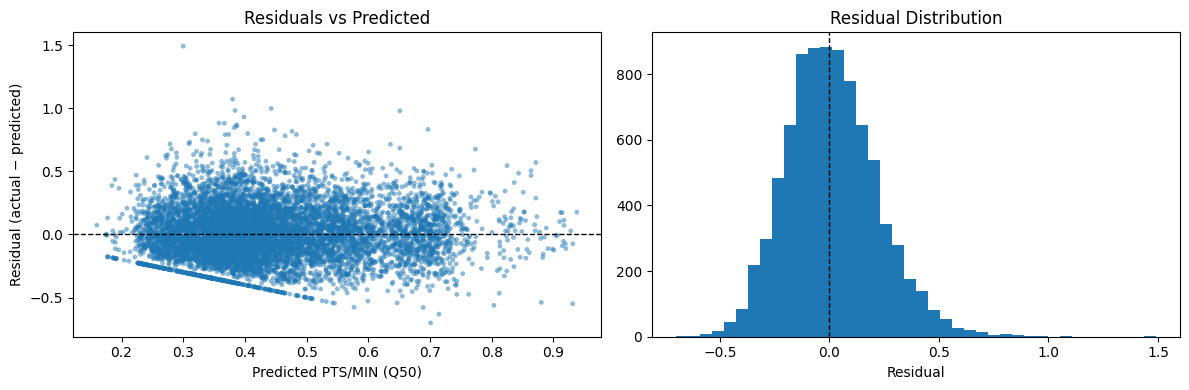


Residual summary:
  mean bias : +0.0109  (close to 0 = unbiased)
  std       : 0.2085

Residuals by role:
  Starters   | n= 4670 | bias=+0.0117 | std=0.1951
  Bench      | n= 3749 | bias=+0.0100 | std=0.2241

Residuals by PPM tier:
  <0.3 pts/min       | n= 2484 | bias=-0.1897 | std=0.1117
  0.3-0.5 pts/min    | n= 2578 | bias=-0.0184 | std=0.1113
  0.5-0.7 pts/min    | n= 2027 | bias=+0.1085 | std=0.1264
  0.7+ pts/min       | n= 1330 | bias=+0.2937 | std=0.1798


In [137]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error

# ── pull directly from stored walk-forward variables ─────────────────────────
# models_last, preds_last, X_val_last, y_val_last, starting_last
# are all set at the end of the walk-forward loop — no reconstruction needed.

y_true    = y_val_last.values
pred_low  = preds_last["q_0.10"]
pred_mid  = preds_last["q_0.50"]
pred_high = preds_last["q_0.90"]

preds_plot = {"Q10": pred_low, "Q50": pred_mid, "Q90": pred_high}

# ── predicted vs actual scatter ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 6), sharex=True, sharey=True)
scatter_metrics = {}

for ax, (name, y_pred) in zip(axes, preds_plot.items()):
    r2  = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    scatter_metrics[name] = {"R2": r2, "MAE": mae}

    ax.scatter(y_true, y_pred, s=12, alpha=0.6, edgecolors="none")
    lims = [0, max(y_true.max(), y_pred.max()) * 1.02]
    ax.plot(lims, lims, "k--", lw=1)
    ax.set_title(f"{name}  |  R²={r2:.3f}  MAE={mae:.4f}")
    ax.set_xlabel("Actual PTS/MIN")
    ax.set_ylabel("Predicted PTS/MIN")
    ax.set_aspect("equal", adjustable="box")
    ax.text(
        0.04, 0.96,
        f"R² = {r2:.3f}\nMAE = {mae:.4f}",
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.85, edgecolor="0.7"),
    )

plt.suptitle(f"Walk-Forward last fold — {last_fold['fold']}", y=1.02)
plt.tight_layout()
plt.show()

print("Per-quantile fit on last validation fold:")
for name, m in scatter_metrics.items():
    print(f"  {name}: R²={m['R2']:+.3f}  MAE={m['MAE']:.4f}")

# ── coverage per quantile ─────────────────────────────────────────────────────
print("\nCoverage per quantile (should match quantile value):")
for name, y_pred in preds_plot.items():
    coverage = (y_true <= y_pred).mean()
    q_target = {"Q10": 0.10, "Q50": 0.50, "Q90": 0.90}[name]
    delta    = coverage - q_target
    flag     = "⚠" if abs(delta) > 0.05 else "✓"
    print(f"  {name}: {coverage:.1%}  (target {q_target:.0%}, delta {delta:+.1%})  {flag}")

# ── interval width ────────────────────────────────────────────────────────────
interval_width = pred_high - pred_low
print(f"\n80% interval width (Q10→Q90):")
print(f"  mean   : {interval_width.mean():.4f} pts/min")
print(f"  median : {np.median(interval_width):.4f} pts/min")
print(f"  std    : {interval_width.std():.4f} pts/min")

# ── residual plot ─────────────────────────────────────────────────────────────
residuals = y_true - pred_mid
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(pred_mid, residuals, s=12, alpha=0.5, edgecolors="none")
axes[0].axhline(0, color="k", lw=1, linestyle="--")
axes[0].set_xlabel("Predicted PTS/MIN (Q50)")
axes[0].set_ylabel("Residual (actual − predicted)")
axes[0].set_title("Residuals vs Predicted")

axes[1].hist(residuals, bins=40, edgecolor="none")
axes[1].axvline(0, color="k", lw=1, linestyle="--")
axes[1].set_xlabel("Residual")
axes[1].set_title("Residual Distribution")

plt.tight_layout()
plt.show()

print(f"\nResidual summary:")
print(f"  mean bias : {residuals.mean():+.4f}  (close to 0 = unbiased)")
print(f"  std       : {residuals.std():.4f}")

# ── residuals stratified by role and PPM tier ──────────────────────────────────
# re-derive starting using X_val_last.index (guaranteed same length as residuals)
starting_last = ppm_df.loc[X_val_last.index, "starting"].values

print("\nResiduals by role:")
for role, mask in [("Starters", starting_last == 1), ("Bench", starting_last == 0)]:
    if mask.sum() == 0:
        continue
    r = residuals[mask]
    print(f"  {role:10s} | n={mask.sum():5d} | bias={r.mean():+.4f} | std={r.std():.4f}")

print("\nResiduals by PPM tier:")
for tier, fn in PPM_TIERS.items():
    mask = fn(y_true)
    if mask.sum() == 0:
        continue
    r = residuals[mask]
    print(f"  {tier:18s} | n={mask.sum():5d} | bias={r.mean():+.4f} | std={r.std():.4f}")

In [138]:
val_df = ppm_df.loc[X_val_last.index].reset_index(drop=True)

pred50 = np.asarray(pred_mid).reshape(-1)
pred90 = np.asarray(pred_high).reshape(-1)
out = pd.DataFrame({
    "player":       val_df["player_name"].values,
    "actual_ppm":   np.asarray(y_true).reshape(-1),
    "pred_ppm_q50": pred50,
    "pred_ppm_q90": pred90,
})
out["error"]     = out["actual_ppm"] - out["pred_ppm_q50"]
out["abs_error"] = out["error"].abs()

if "game_date" in val_df.columns:
    out["game_date"] = val_df["game_date"].values

print(out.sort_values("abs_error", ascending=True).head(20).to_string(index=False))
print(f"\nMAE (Q50): {out['abs_error'].mean():.4f} | RMSE: {np.sqrt((out['error']**2).mean()):.4f}")

                  player  actual_ppm  pred_ppm_q50  pred_ppm_q90     error  abs_error  game_date
         Lauri Markkanen    0.563204      0.563206      0.848801 -0.000002   0.000002 2025-01-04
       Haywood Highsmith    0.247140      0.247130      0.490667  0.000010   0.000010 2025-01-13
         Kelly Oubre Jr.    0.389821      0.389810      0.635528  0.000011   0.000011 2024-11-24
               Kris Dunn    0.289366      0.289393      0.557155 -0.000027   0.000027 2025-01-02
Nickeil Alexander-Walker    0.376569      0.376656      0.643535 -0.000087   0.000087 2024-12-29
         Christian Braun    0.431433      0.431323      0.677370  0.000110   0.000110 2024-11-25
              RJ Barrett    0.644053      0.643907      0.911528  0.000147   0.000147 2024-11-29
            Jakob Poeltl    0.451411      0.451577      0.695967 -0.000166   0.000166 2025-01-29
          Brandon Miller    0.559503      0.559329      0.835457  0.000174   0.000174 2024-11-27
               Paul Reed    0.


── q_0.10 ──


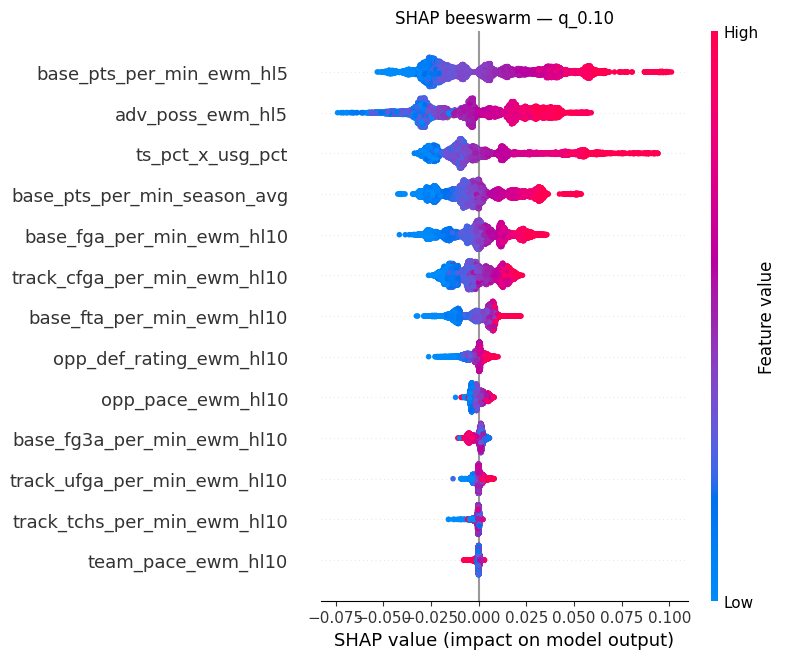


── q_0.50 ──


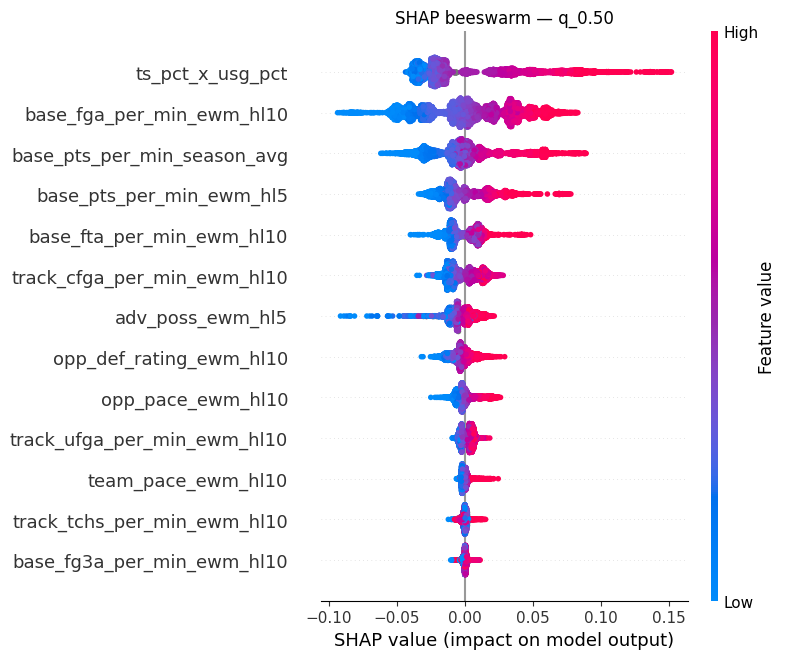


── q_0.90 ──


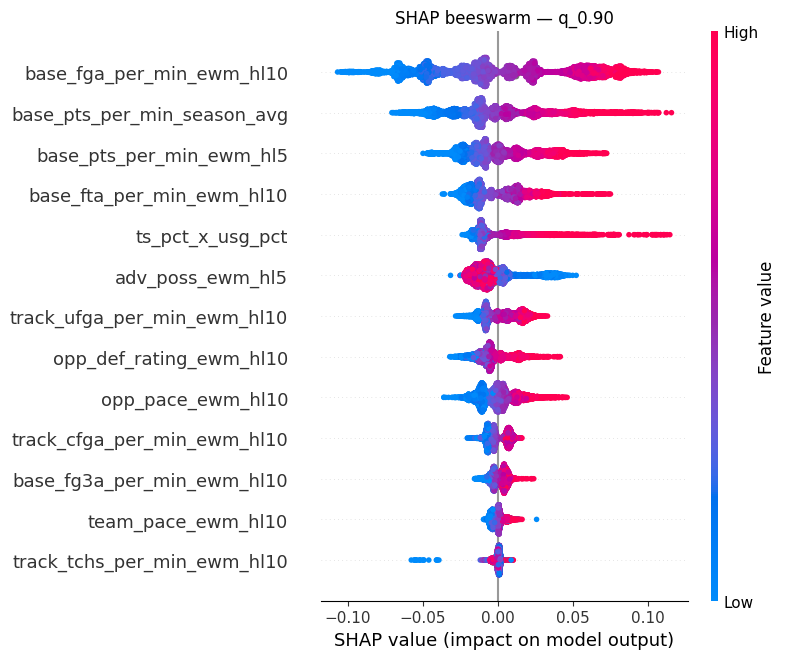

In [139]:
import shap

for q_key, model in models_last.items():
    explainer   = shap.TreeExplainer(model, model_output="raw")
    shap_values = explainer(X_val_last)

    print(f"\n── {q_key} ──")
    shap.plots.beeswarm(shap_values, max_display=30, show=False)
    plt.title(f"SHAP beeswarm — {q_key}")
    plt.tight_layout()
    plt.show()

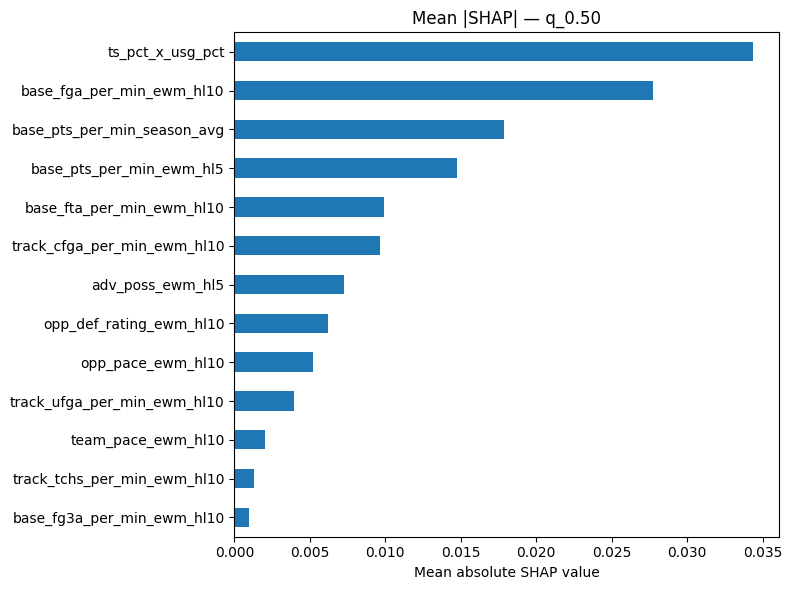

In [140]:
model = models_last["q_0.50"]

explainer   = shap.TreeExplainer(model, model_output="raw")
shap_values = explainer(X_val_last)

mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
feat_imp = pd.Series(mean_abs_shap, index=FEATURE_COLS).sort_values(ascending=True)

ax = feat_imp.plot(kind="barh", figsize=(8, 6))
ax.set_title("Mean |SHAP| — q_0.50")
ax.set_xlabel("Mean absolute SHAP value")
plt.tight_layout()
plt.show()


In [141]:
# ── Permutation importance — on VALIDATION set ───────────────────────────────
from sklearn.inspection import permutation_importance
from sklearn.metrics import make_scorer
from scipy import stats as sp_stats

def pinball_50(y_true, y_pred, alpha=0.50):
    residual = y_true - y_pred
    return -np.mean(np.where(residual >= 0, alpha * residual, (alpha - 1) * residual))

result = permutation_importance(
    models_last["q_0.50"],
    X_val_last,
    y_val_last,
    n_repeats=30,
    random_state=42,
    scoring=make_scorer(pinball_50),
)

pi_df = (
    pd.DataFrame({
        "feature":    X_val_last.columns,
        "importance": result.importances_mean,
        "std":        result.importances_std,
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)
pi_df.index += 1
pi_df["importance"] = pi_df["importance"].round(6)
pi_df["std"]        = pi_df["std"].round(6)

pi_df["p_value"] = sp_stats.ttest_1samp(
    result.importances, 0.0, axis=1
).pvalue.round(4)
pi_df["significant"] = pi_df["p_value"] < 0.05

print("Permutation importance (val set) — higher = more important, significant = p<0.05")
print(pi_df.to_string())

Permutation importance (val set) — higher = more important, significant = p<0.05
                        feature  importance       std  p_value  significant
1     base_fga_per_min_ewm_hl10    0.003092  0.000154      0.0         True
2              ts_pct_x_usg_pct    0.002636  0.000135      0.0         True
3   base_pts_per_min_season_avg    0.001538  0.000106      0.0         True
4      base_pts_per_min_ewm_hl5    0.000939  0.000070      0.0         True
5              adv_poss_ewm_hl5    0.000837  0.000104      0.0         True
6     base_fta_per_min_ewm_hl10    0.000554  0.000073      0.0         True
7   track_cfga_per_min_ewm_hl10    0.000433  0.000058      0.0         True
8       opp_def_rating_ewm_hl10    0.000187  0.000050      0.0         True
9   track_ufga_per_min_ewm_hl10    0.000171  0.000027      0.0         True
10            opp_pace_ewm_hl10    0.000136  0.000045      0.0         True
11           team_pace_ewm_hl10    0.000051  0.000019      0.0         True
12  tra

In [142]:
from sklearn.metrics import mean_squared_error

# ── pull train/val slices from last fold's stored masks ───────────────────────
train_mask_last = last_fold["train_mask"]
val_mask_last   = last_fold["val_mask"]

X_tr_last = X[train_mask_last]
X_va_last = X[val_mask_last]
y_tr_last = y[train_mask_last]
y_va_last = y[val_mask_last]


def rmse_median_ablation(feature_cols):
    m = XGBRegressor(**XGB_PARAMS, quantile_alpha=0.50)
    m.fit(
        X_tr_last[feature_cols], y_tr_last,
        eval_set=[(X_va_last[feature_cols], y_va_last)],
        verbose=False,
    )
    pred = m.predict(X_va_last[feature_cols])
    return float(np.sqrt(mean_squared_error(y_va_last, pred)))


baseline_rmse = rmse_median_ablation(FEATURE_COLS)
print(f"Baseline RMSE (all features): {baseline_rmse:.6f}")

rows = []
for feat in FEATURE_COLS:
    cols         = [c for c in FEATURE_COLS if c != feat]
    ablated_rmse = rmse_median_ablation(cols)
    delta        = ablated_rmse - baseline_rmse  # positive = removing it hurt = feature helped
    rows.append({"feature": feat, "ablated_rmse": round(ablated_rmse, 6), "delta_rmse": round(delta, 6)})

ablation_df = (
    pd.DataFrame(rows)
    .sort_values("delta_rmse", ascending=False)
    .reset_index(drop=True)
)
ablation_df.index += 1
print(ablation_df.to_string())


Baseline RMSE (all features): 0.208812
                        feature  ablated_rmse  delta_rmse
1              adv_poss_ewm_hl5      0.209050    0.000238
2             opp_pace_ewm_hl10      0.209042    0.000230
3      base_pts_per_min_ewm_hl5      0.209042    0.000230
4       opp_def_rating_ewm_hl10      0.208972    0.000160
5     base_fga_per_min_ewm_hl10      0.208968    0.000157
6   base_pts_per_min_season_avg      0.208966    0.000154
7            team_pace_ewm_hl10      0.208906    0.000094
8   track_tchs_per_min_ewm_hl10      0.208897    0.000086
9     base_fta_per_min_ewm_hl10      0.208863    0.000051
10  track_ufga_per_min_ewm_hl10      0.208850    0.000038
11  track_cfga_per_min_ewm_hl10      0.208847    0.000035
12   base_fg3a_per_min_ewm_hl10      0.208826    0.000014
13             ts_pct_x_usg_pct      0.208819    0.000007


In [143]:
from scipy import stats

# ── all three methods use the val set for consistency ─────────────────────────
model = models_last["q_0.50"]

_shap_expl     = shap.TreeExplainer(model, model_output="raw")
_shap_vals     = _shap_expl(X_val_last)                        # ← val set, not X_tr
_mean_abs_shap = np.abs(_shap_vals.values).mean(axis=0)

shap_table = pd.DataFrame({
    "feature":       X_val_last.columns,
    "mean_abs_shap": _mean_abs_shap,
}).assign(
    shap_rank=lambda d: d["mean_abs_shap"].rank(method="min", ascending=False).astype(int)
)

perm_table = (
    pi_df.sort_values("importance", ascending=False)
    .reset_index(drop=True)
    .rename(columns={"importance": "perm_importance", "std": "perm_importance_std"})
)
perm_table["perm_rank"] = np.arange(1, len(perm_table) + 1)
perm_table = perm_table[["feature", "perm_rank", "perm_importance", "perm_importance_std"]]

perm_pv = pd.DataFrame({
    "feature":    X_val_last.columns,
    "perm_pvalue": stats.ttest_1samp(
        result.importances, 0.0, axis=1, nan_policy="omit"
    ).pvalue,
})

abla = ablation_df[["feature", "delta_rmse"]].rename(columns={"delta_rmse": "ablation_delta"})

feature_audit = (
    pd.DataFrame({"feature": FEATURE_COLS})
    .merge(shap_table, on="feature", how="left")
    .merge(perm_table, on="feature", how="left")
    .merge(perm_pv,    on="feature", how="left")
    .merge(abla,       on="feature", how="left")
)

_ms       = feature_audit["mean_abs_shap"].astype(float)
_mp       = feature_audit["perm_importance"].astype(float)
_max_shap = _ms.fillna(0).max()
_max_perm = _mp.fillna(0).max()

feature_audit["shap_norm"] = np.where(_max_shap > 0, _ms.fillna(0) / _max_shap, 0.0)
feature_audit["perm_norm"] = np.where(_max_perm > 0, _mp.fillna(0) / _max_perm, 0.0)
feature_audit["consensus"] = (feature_audit["shap_norm"] + feature_audit["perm_norm"]) / 2

feature_audit = feature_audit.sort_values("consensus", ascending=False).reset_index(drop=True)
feature_audit.index += 1

# flag features that are significant in perm AND positive in ablation
feature_audit["keep"] = (
    (feature_audit["perm_pvalue"] < 0.05) &
    (feature_audit["ablation_delta"] > 0)
)

print(feature_audit.to_string())


                        feature  mean_abs_shap  shap_rank  perm_rank  perm_importance  perm_importance_std   perm_pvalue  ablation_delta  shap_norm  perm_norm  consensus  keep
1              ts_pct_x_usg_pct       0.034360          1          2         0.002636             0.000135  5.798629e-39        0.000007   1.000000   0.852523   0.926261  True
2     base_fga_per_min_ewm_hl10       0.027745          2          1         0.003092             0.000154  2.332452e-39        0.000157   0.807478   1.000000   0.903739  True
3   base_pts_per_min_season_avg       0.017896          3          3         0.001538             0.000106  2.547457e-35        0.000154   0.520835   0.497413   0.509124  True
4      base_pts_per_min_ewm_hl5       0.014765          4          4         0.000939             0.000070  2.391687e-34        0.000230   0.429708   0.303687   0.366698  True
5              adv_poss_ewm_hl5       0.007276          7          5         0.000837             0.000104  6.186213e-28

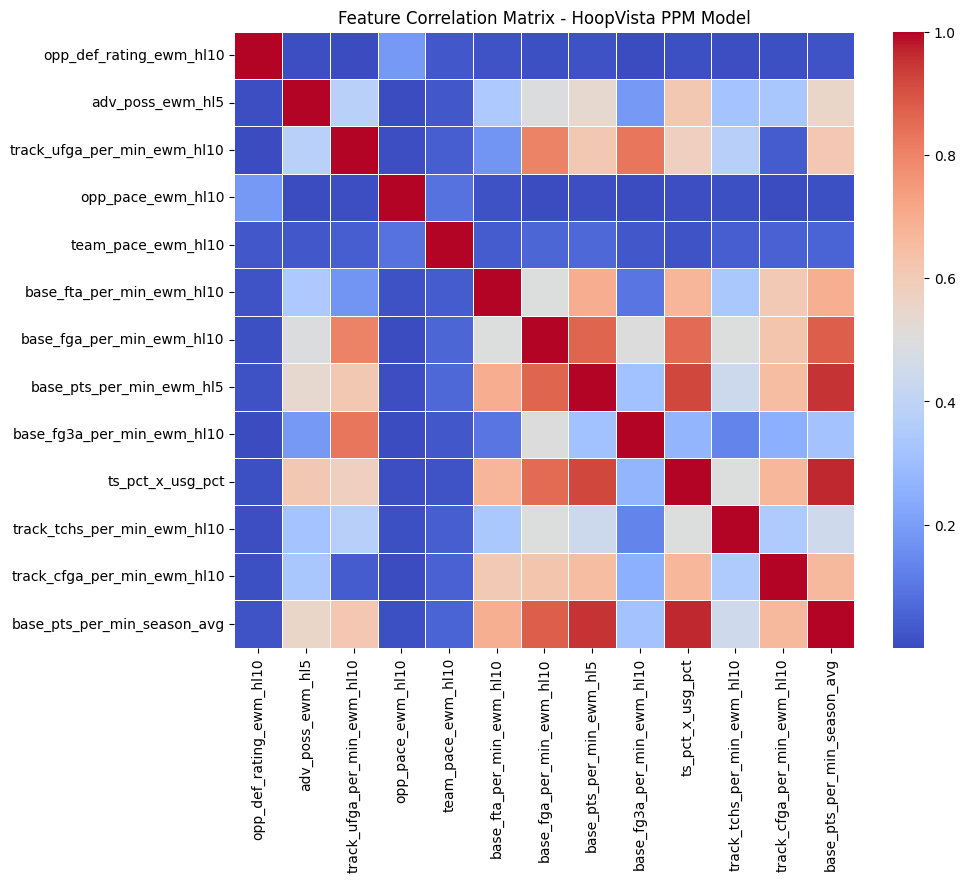

--- High Correlation Report (Threshold > 0.95) ---
base_pts_per_min_season_avg <-> ts_pct_x_usg_pct: 0.9651
base_pts_per_min_season_avg <-> base_pts_per_min_ewm_hl5: 0.9527


['base_pts_per_min_season_avg']

In [144]:
import seaborn as sns

def analyze_correlations(df, features, threshold=0.95):
    """
    Analyzes feature correlations to identify redundancy in the PPM model.
    """
    corr_matrix = df[features].corr().abs()

    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]

    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
    plt.title(f'Feature Correlation Matrix - HoopVista PPM Model')
    plt.show()

    print(f"--- High Correlation Report (Threshold > {threshold}) ---")
    high_corr_pairs = []
    for col in upper.columns:
        connected = upper.index[upper[col] > threshold].tolist()
        for c in connected:
            high_corr_pairs.append((col, c, upper.loc[c, col]))

    if not high_corr_pairs:
        print("No features exceed the correlation threshold.")
    else:
        for f1, f2, val in sorted(high_corr_pairs, key=lambda x: x[2], reverse=True):
            print(f"{f1} <-> {f2}: {val:.4f}")

    return to_drop

correlated_features = analyze_correlations(df, FEATURE_COLS)
correlated_features


In [145]:
# ════════════════════════════════════════════════════════════════════════════
# BLIND HOLDOUT TEST — S26
#
# NEW: evaluate on the season the model never saw during development.
# Run this cell once. If you iterate after seeing these numbers,
# S26 is no longer a clean holdout.
# ════════════════════════════════════════════════════════════════════════════

print("── S26 Blind Holdout Evaluation ─────────────────────────────────────")
print("  S22–S25: 90% rows for fit, last 10% for early-stopping only; predict S26 (never in eval_set).")

X_train_full = ppm_df[FEATURE_COLS]
y_train_full = ppm_df["pts_per_min"]
X_ho         = ppm_holdout[FEATURE_COLS]
y_ho         = ppm_holdout["pts_per_min"]
starting_ho  = ppm_holdout["starting"].values

# Early stopping on last 10% of training only — S26 must not be eval_set
# or best_iteration is tuned to the holdout.
es_cutoff  = int(len(X_train_full) * 0.90)
X_es_train = X_train_full.iloc[:es_cutoff]
y_es_train = y_train_full.iloc[:es_cutoff]
X_es_val   = X_train_full.iloc[es_cutoff:]
y_es_val   = y_train_full.iloc[es_cutoff:]

models_ho, _ = fit_quantile_models(X_es_train, y_es_train, X_es_val, y_es_val)
preds_ho = {k: models_ho[k].predict(X_ho) for k in models_ho}

ho_metrics = score_fold(
    y_ho.values, preds_ho, models_ho,
    "S26 Blind Holdout",
    starting=starting_ho
)

# Compare walk-forward MAE vs holdout MAE — gap indicates how optimistic
# the WF estimate was
wf_mae_mean = np.mean([r["mae"] for r in wf_results])
ho_mae      = ho_metrics["mae"]
gap         = ho_mae - wf_mae_mean

print(f"\n{'─'*55}")
print(f"  Walk-forward MAE (mean, S22–S25)  : {wf_mae_mean:.4f}")
print(f"  Holdout MAE      (S26)            : {ho_mae:.4f}")
print(f"  Gap                               : {gap:+.4f}  {'⚠ investigate' if abs(gap) > 0.05 else '✓ acceptable'}")

# Per-quantile calibration on holdout
print(f"\nHoldout quantile calibration (should match target):")
for q_key, target in [("q_0.10", 0.10), ("q_0.50", 0.50), ("q_0.90", 0.90)]:
    pred           = preds_ho[q_key]
    actual         = y_ho.values
    actual_coverage = (actual <= pred).mean()
    delta          = actual_coverage - target
    flag           = "⚠" if abs(delta) > 0.05 else "✓"
    print(f"  {q_key} | actual coverage: {actual_coverage:.1%}  target: {target:.0%}  delta: {delta:+.1%}  {flag}")

# Interval width on holdout
interval_width = preds_ho["q_0.90"] - preds_ho["q_0.10"]
print(f"\nHoldout 80% interval width (Q10→Q90):")
print(f"  mean: {interval_width.mean():.4f}  |  median: {np.median(interval_width):.4f}  |  std: {interval_width.std():.4f}")


── S26 Blind Holdout Evaluation ─────────────────────────────────────
  S22–S25: 90% rows for fit, last 10% for early-stopping only; predict S26 (never in eval_set).

S26 Blind Holdout
  Overall  | n=22725 | MAE: 0.1677 | R²: 0.270 | 80% Coverage: 79.4%
  Starters   | n=12300 | MAE: 0.1604 | Coverage: 80.3%
  Bench      | n=10425 | MAE: 0.1764 | Coverage: 78.5%
  <0.3 pts/min       | n= 6359 | MAE: 0.1972 | Coverage: 67.1%
  0.3-0.5 pts/min    | n= 7062 | MAE: 0.0892 | Coverage: 96.9%
  0.5-0.7 pts/min    | n= 5473 | MAE: 0.1428 | Coverage: 91.7%
  0.7+ pts/min       | n= 3831 | MAE: 0.2990 | Coverage: 50.3%

───────────────────────────────────────────────────────
  Walk-forward MAE (mean, S22–S25)  : 0.1643
  Holdout MAE      (S26)            : 0.1677
  Gap                               : +0.0034  ✓ acceptable

Holdout quantile calibration (should match target):
  q_0.10 | actual coverage: 10.2%  target: 10%  delta: +0.2%  ✓
  q_0.50 | actual coverage: 49.8%  target: 50%  delta: -0.2%

In [146]:
import joblib
from pathlib import Path

# ── resolve save directory relative to this notebook ─────────────────────────
# Works on any machine regardless of OS or username.
# Structure: <repo_root>/src/models/saved_models/
# Assumes notebook lives somewhere inside the repo (e.g. notebooks/ or root).

REPO_ROOT = Path(__file__).resolve().parents[1] if "__file__" in dir() else Path.cwd()
save_dir  = REPO_ROOT / "src" / "models" / "saved_models"
save_dir.mkdir(parents=True, exist_ok=True)

# ── save ──────────────────────────────────────────────────────────────────────
bundle = {
    "quantile_models": models_ho,
    "feature_names":   FEATURE_COLS,
    "fold_metrics":    wf_results,
    "holdout_metrics": ho_metrics,
    "train_end":       ppm_df["game_date"].max(),
    "val_end":         ppm_holdout["game_date"].max(),
}

save_path = save_dir / f"ppm_nba_model_{ppm_holdout['game_date'].max().date()}.joblib"
joblib.dump(bundle, save_path)
print(f"Saved to {save_path}")

# ── load ──────────────────────────────────────────────────────────────────────
bundle        = joblib.load(save_path)
models_loaded = bundle["quantile_models"]
feature_names = bundle["feature_names"]

test_preds = models_loaded["q_0.50"].predict(X_ho)
print(f"Loaded model MAE (S26 holdout): {mean_absolute_error(y_ho, test_preds):.4f}")
print(f"Trained on data up to        : {bundle['train_end'].date()}")
print(f"Holdout through              : {bundle['val_end'].date()}")

# ── inference ─────────────────────────────────────────────────────────────────
def predict_ppm(player_features: pd.DataFrame) -> pd.DataFrame:
    """
    Pass in a DataFrame with the same columns as FEATURE_COLS.
    Returns Q10 / Q50 / Q90 predictions per row.
    """
    assert list(player_features.columns) == feature_names, \
        f"Feature mismatch — expected {feature_names}"

    return pd.DataFrame({
        "q10": models_loaded["q_0.10"].predict(player_features),
        "q50": models_loaded["q_0.50"].predict(player_features),
        "q90": models_loaded["q_0.90"].predict(player_features),
    })


Saved to /Users/alexgonzalez/Documents/NBA-Prop-Predictor/src/models/saved_models/ppm_nba_model_2026-04-12.joblib
Loaded model MAE (S26 holdout): 0.1677
Trained on data up to        : 2025-04-13
Holdout through              : 2026-04-12
